In [3]:
# training data
arm=[40, 30, 20, 70, 60]
leg=[30, 80, 70, 40, 20]
gen=[1, -1, -1, 1, 1]
print(arm,leg,gen)

[40, 30, 20, 70, 60] [30, 80, 70, 40, 20] [1, -1, -1, 1, 1]


In [4]:
# differential
import sympy as sym
a=sym.Symbol('a')
b=sym.Symbol('b')
c=sym.Symbol('c')
R=0

# Residual
for i in range(0,5):
   R+=(arm[i]*a+leg[i]*b+c-gen[i])**2

R_a=sym.diff(R,a)
R_b=sym.diff(R,b)
R_c=sym.diff(R,c)
print("Result of differentiating with respect to a:", R_a, "= 0")
print("Result of differentiating with respect to b:", R_b, "= 0")
print("Result of differentiating with respect to c:", R_c, "= 0")

Result of differentiating with respect to a: 22800*a + 18000*b + 440*c - 240 = 0
Result of differentiating with respect to b: 18000*a + 28400*b + 480*c + 120 = 0
Result of differentiating with respect to c: 440*a + 480*b + 10*c - 2 = 0


In [5]:
# Solve a,b,c using matrix operations

import numpy as np
# A=[[22800,18000,440],[18000,28400,480],[440,480,10]]
# B=[240,-120,2]
A = [[1756982.16180000, 186.140000000000], [186.140000000000, 200.000000000000]]
B = [135980477339.877, 75795193.4000000]
inv_A=np.linalg.inv(A)
result=np.dot(inv_A,B)
print("a=",result[0]," b=",result[1])
# print("a=",result[0]," b=",result[1]," c=",result[2])
a=result[0]
b=result[1]
# c=result[2]

a= 77361.81954987714  b= 306975.32154492935


In [6]:
%matplotlib notebook

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = arm
y = leg
z = gen

X = np.arange(-0.5, 1.5, 0.1)*100
Y = np.arange(-0.5, 1.5, 0.1)*100
X, Y = np.meshgrid(X, Y)
Z = (float(-0.027) * Y) + (float(0.021) * X) + float(0.599)

ax.plot(x, y, z, linestyle="none", marker="o", mfc="none", markeredgecolor="k") #샘플 출력
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.4, cmap=cm.Blues) # 평면 출력
ax.plot([-50, 100], [-16.7037, 99.9629], [0,0],'r-') # 선 출력

plt.show()

<IPython.core.display.Javascript object>

In [7]:
def animal(x, y):
    # result = a * x + b * y + c
    result = a * x + b * y
    if result > 0:
        return "male"
    return "female"

print("The input animal is judged by the trained model as", animal(50, 30) + ".")

The input animal is judged by the trained model as male.


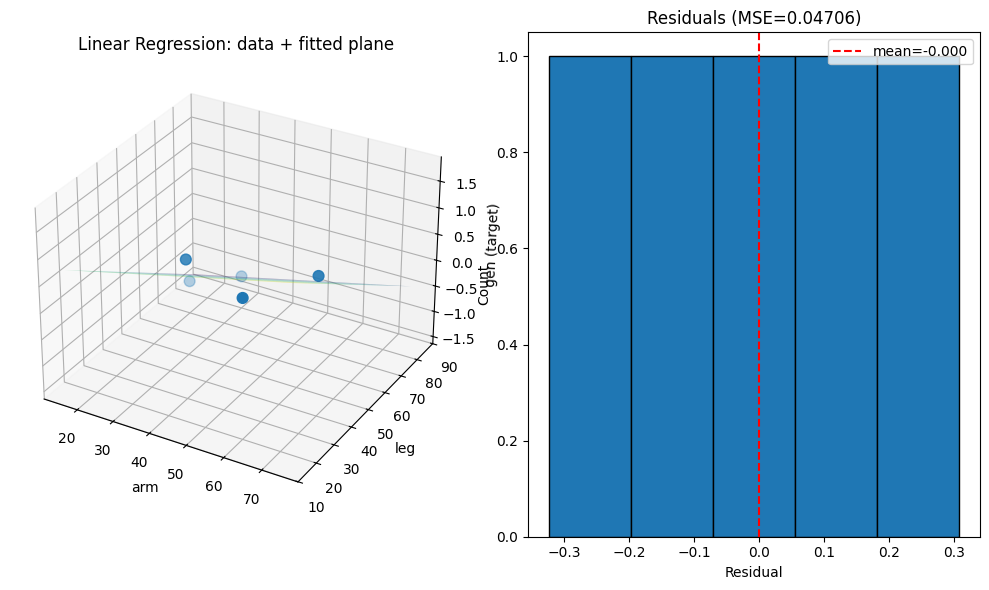

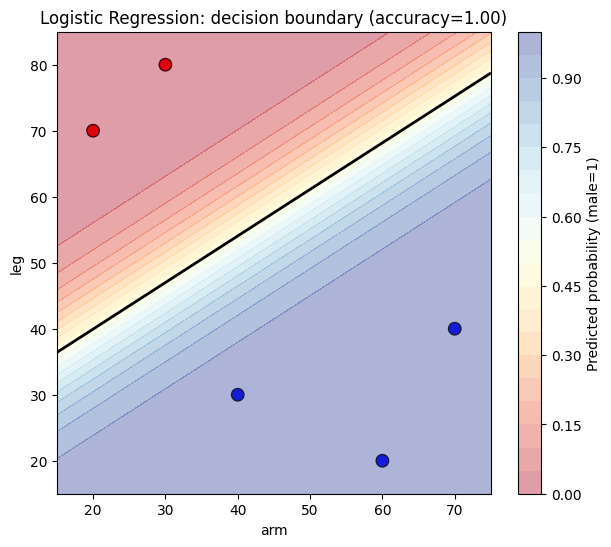

Linear regression theta (w1, w2, bias):
[ 0.01617647 -0.03088235  0.97058824]

Linear predictions:
  x=(40.0,30.0), y_true=1.000, y_pred=0.691
  x=(30.0,80.0), y_true=-1.000, y_pred=-1.015
  x=(20.0,70.0), y_true=-1.000, y_pred=-0.868
  x=(70.0,40.0), y_true=1.000, y_pred=0.868
  x=(60.0,20.0), y_true=1.000, y_pred=1.324

Linear MSE: 0.047059

Logistic theta (scaled features):
[ 2.39395823 -4.23455819  1.62385602]
Logistic predicted probabilities:
[0.988 0.002 0.004 0.998 1.   ]
Logistic predicted labels (0/1):
[1 0 0 1 1]
True logistic labels (0/1):
[1 0 0 1 1]
Logistic accuracy: 1.000

Example predictions:
 input (50,30) -> linear: 0.8529411764705898
 input (50,30) -> logistic p=0.997, label=1


C:\Users\Admin\AppData\Local\Temp\ipykernel_22276\4200167065.py:142: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  x=({xi[0]:.1f},{xi[1]:.1f}), y_true={float(y):.3f}, y_pred={float(yp):.3f}")
C:\Users\Admin\AppData\Local\Temp\ipykernel_22276\4200167065.py:159: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x @ theta_lin)
C:\Users\Admin\AppData\Local\Temp\ipykernel_22276\4200167065.py:167: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = float

In [1]:
"""
Integrated Linear Regression + Logistic Regression demo
- Linear: closed-form theta = (X^T X)^-1 X^T y
- Logistic: gradient descent on log-loss with sigmoid
- Plots:
  * 3D scatter + regression plane (linear)
  * residuals (histogram) and MSE
  * 2D scatter + logistic decision boundary and predicted probabilities
  * accuracy for logistic
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# ---------- Data ----------
arm = np.array([40, 30, 20, 70, 60], dtype=float)
leg = np.array([30, 80, 70, 40, 20], dtype=float)
# original labels: -1 or 1 (you used these earlier)
gen_raw = np.array([1, -1, -1, 1, 1], dtype=float)

# For linear regression keep original labels (can be -1/1)
Y_linear = gen_raw.reshape(-1, 1)

# For logistic regression convert labels to 0/1
Y_logistic = ((gen_raw + 1) / 2).astype(int).reshape(-1, 1)  # -1->0, 1->1

# Design matrix with bias term
X = np.column_stack([arm, leg, np.ones_like(arm)])  # shape (n, 3)

# ---------- Linear Regression (closed-form) ----------
def linear_closed_form(X, Y):
    XtX = X.T @ X
    try:
        theta = np.linalg.inv(XtX) @ X.T @ Y
    except np.linalg.LinAlgError:
        theta = np.linalg.pinv(XtX) @ X.T @ Y
    return theta

theta_lin = linear_closed_form(X, Y_linear)  # shape (3,1)

# Predictions and residuals
Y_pred_lin = X @ theta_lin
residuals = (Y_linear - Y_pred_lin).reshape(-1)
mse = float(np.mean((residuals)**2))

# ---------- Logistic Regression (batch gradient descent) ----------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_gradient_descent(X, Y, lr=0.0005, epochs=20000, verbose=False):
    n, d = X.shape
    theta = np.zeros((d,1))
    for it in range(epochs):
        z = X @ theta          # (n,1)
        h = sigmoid(z)         # (n,1)
        # gradient of logistic loss (average)
        grad = (X.T @ (h - Y)) / n
        theta -= lr * grad
        if verbose and (it % (epochs//5) == 0):
            # compute loss
            eps = 1e-12
            loss = - np.mean(Y*np.log(h+eps) + (1-Y)*np.log(1-h+eps))
            print(f"iter {it}, loss={loss:.6f}")
    return theta

# Train logistic
# Scale features a bit to help gradient descent (optional)
X_log = X.copy().astype(float)
# simple feature scaling (mean centering)
X_log[:,0] = (X_log[:,0] - X_log[:,0].mean()) / (X_log[:,0].std() + 1e-9)
X_log[:,1] = (X_log[:,1] - X_log[:,1].mean()) / (X_log[:,1].std() + 1e-9)

theta_log = logistic_gradient_descent(X_log, Y_logistic, lr=0.05, epochs=5000, verbose=False)

# Logistic predictions & accuracy
probs = sigmoid(X_log @ theta_log)
pred_labels = (probs >= 0.5).astype(int)
accuracy = float(np.mean(pred_labels == Y_logistic))

# ---------- Plots ----------
plt.rcParams.update({'figure.max_open_warning': 0})

# 1) 3D scatter + linear regression plane
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(arm, leg, gen_raw, marker='o', s=60, label='Data (gen)')
# create meshgrid for plane
xx = np.linspace(min(arm)-5, max(arm)+5, 20)
yy = np.linspace(min(leg)-5, max(leg)+5, 20)
XX, YY = np.meshgrid(xx, yy)
# plane: z = theta0*x + theta1*y + bias
Z_plane = theta_lin[0,0]*XX + theta_lin[1,0]*YY + theta_lin[2,0]
ax.plot_surface(XX, YY, Z_plane, alpha=0.4, cmap=cm.viridis)
ax.set_xlabel('arm'); ax.set_ylabel('leg'); ax.set_zlabel('gen (target)')
ax.set_title('Linear Regression: data + fitted plane')

# 2) residuals histogram + MSE
ax2 = fig.add_subplot(122)
ax2.hist(residuals, bins=5, edgecolor='k')
ax2.axvline(np.mean(residuals), color='r', linestyle='--', label=f'mean={np.mean(residuals):.3f}')
ax2.set_title(f'Residuals (MSE={mse:.5f})')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()

# 3) Logistic: 2D scatter + decision boundary (in original feature scale)
fig2, ax = plt.subplots(figsize=(7,6))
# scatter points colored by true label (0/1 -> female/male)
colors = ['red' if y==0 else 'blue' for y in Y_logistic.flatten()]
ax.scatter(arm, leg, c=colors, edgecolor='k', s=80, label='data')

# decision boundary: evaluate probability over grid (using scaled features)
grid_x = np.linspace(min(arm)-5, max(arm)+5, 200)
grid_y = np.linspace(min(leg)-5, max(leg)+5, 200)
GX, GY = np.meshgrid(grid_x, grid_y)
G_flat = np.column_stack([GX.ravel(), GY.ravel(), np.ones_like(GX.ravel())])
# apply same scaling used for training
G_scaled = G_flat.copy().astype(float)
G_scaled[:,0] = (G_scaled[:,0] - X[:,0].mean()) / (X[:,0].std() + 1e-9)
G_scaled[:,1] = (G_scaled[:,1] - X[:,1].mean()) / (X[:,1].std() + 1e-9)
probs_grid = sigmoid(G_scaled @ theta_log).reshape(GX.shape)

# contour for probability
cs = ax.contourf(GX, GY, probs_grid, levels=20, alpha=0.4, cmap='RdYlBu')
# decision boundary line at prob=0.5
ax.contour(GX, GY, probs_grid, levels=[0.5], colors='k', linewidths=2)

ax.set_xlabel('arm'); ax.set_ylabel('leg')
ax.set_title(f'Logistic Regression: decision boundary (accuracy={accuracy:.2f})')
plt.colorbar(cs, label='Predicted probability (male=1)')
plt.show()

# 4) Print results
print("Linear regression theta (w1, w2, bias):")
print(theta_lin.flatten())
print("\nLinear predictions:")
for xi, yp, y in zip(X, Y_pred_lin, Y_linear):
    print(f"  x=({xi[0]:.1f},{xi[1]:.1f}), y_true={float(y):.3f}, y_pred={float(yp):.3f}")

print(f"\nLinear MSE: {mse:.6f}")

print("\nLogistic theta (scaled features):")
print(theta_log.flatten())
print("Logistic predicted probabilities:")
print(np.round(probs.flatten(), 3))
print("Logistic predicted labels (0/1):")
print(pred_labels.flatten())
print("True logistic labels (0/1):")
print(Y_logistic.flatten())
print(f"Logistic accuracy: {accuracy:.3f}")

# 5) Example decision function for a new sample
def predict_linear(x_arm, x_leg):
    x = np.array([x_arm, x_leg, 1.0])
    return float(x @ theta_lin)

def predict_logistic(x_arm, x_leg):
    x = np.array([x_arm, x_leg, 1.0])
    # scale like training
    x_scaled = x.copy().astype(float)
    x_scaled[0] = (x_scaled[0] - X[:,0].mean()) / (X[:,0].std() + 1e-9)
    x_scaled[1] = (x_scaled[1] - X[:,1].mean()) / (X[:,1].std() + 1e-9)
    p = float(sigmoid(x_scaled @ theta_log))
    return p, int(p>=0.5)

print("\nExample predictions:")
print(" input (50,30) -> linear:", predict_linear(50,30))
p,lab = predict_logistic(50,30)
print(f" input (50,30) -> logistic p={p:.3f}, label={lab}")
